# NEURAL NETWORK CLASSIFICATION WITH PYTORCH
There any be multiple classes in a classification problem


## Make classificationd data and get it ready

In [78]:
import sklearn

In [79]:
from sklearn.datasets import make_circles

n_sample = 1000

X, y = make_circles(n_sample, noise=0.03, random_state=42)

In [80]:
len(X), len(y)

(1000, 1000)

In [81]:
print(f"First 5 sample of X:\n {X[:5]}")
print(f"First 5 sample of y:\n {y[:5]}")

First 5 sample of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 sample of y:
 [1 1 1 1 0]


In [82]:
# Make Dataframe of circle data
import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0],"X2":X[:,1],"label":y})
circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


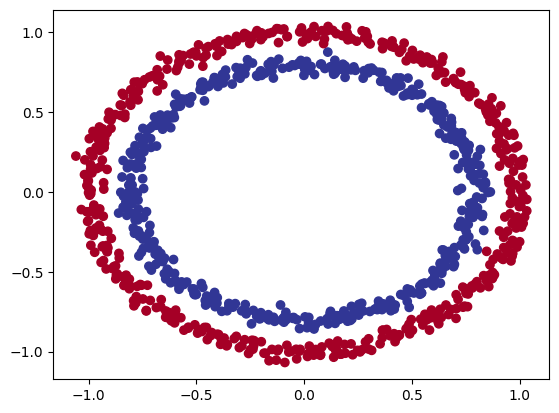

In [83]:
# Visualize
import matplotlib.pyplot as plt
plt.scatter(X[:, 0],X[:,1],c=y, cmap= plt.cm.RdYlBu)

### Check input and output shape

In [84]:
X.shape, y.shape

((1000, 2), (1000,))

## 1.2 Turn data into tensor to work with pytorch

In [85]:
import torch

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [86]:
# Split the data randomly
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Building a Model

1. Setup device agnostic code
2. Construct a model by subclassing nn.module
3. define lossfn and optimizer

In [87]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

1. Subclass `nn.Module`
2. Create 2 `nn.Linear()` layer that are capable of handling the shapes of our data
3. Define a `forward()` method
4. Instantiate an instance of our model class and send it to the target device

In [88]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.layer_2(self.layer_1(x))

torch.manual_seed(42)
model_0 = CircleModelV0().to(device)
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]])),
             ('layer_1.bias',
              tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410])),
             ('layer_2.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]])),
             ('layer_2.bias', tensor([-0.2060]))])

In [89]:
# Lets replicate the model above using nn.sequential

model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)
torch.manual_seed(42)
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]])),
             ('0.bias', tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370])),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]])),
             ('1.bias', tensor([-0.1213]))])

In [90]:
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))


### 2.1 Setup loss func and optmizer
Which loss fn and optim should we use
* for regression  - MAE / MSE
* for classsification - binary cross-entropy (BCE) or categorical cross entropy

Optim most common is ADAM and SGD

In [91]:
# Setup loss fn
# loss_fn = nn.BCELoss() # require the input to have gone through the sigmoid activation func priod to input ot BSCLoss
loss_fn = nn.BCEWithLogitsLoss() # has sigmoid activaation build in

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)


In [92]:
# Calculate Accuracy - out of 100 examples, what percentage does our model get right
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true.to(device), y_pred.to(device)).sum().item()
  acc = (correct/ len(y_pred)) * 100
  return acc

## 3. train our model we have to build the training loop
raw logits -> prediction probabilities -> prediction labels
model outputs are going to be raw logits, we convert them into probabilities using some kind of activation using sigmoid or softmax, then we can round them to label by rounding or using argmax

In [93]:
y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], grad_fn=<SliceBackward0>)

In [94]:
# Use sigmoid on our logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], grad_fn=<SigmoidBackward0>)

In [95]:
torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]], grad_fn=<RoundBackward0>)

## For prediction probability value we need to set the decision boundary
`y_pred_probs` > 5 = 1
`y_pred_probs` < 5 = 0

In [96]:
y_preds = torch.round(y_pred_probs)

# in one single line
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

tensor([True, True, True, True, True])


In [97]:
torch.cuda.manual_seed(42) if torch.cuda.is_available() else torch.manual_seed(42)
epochs = 300

X_train, y_train, X_test, y_test = X_train.to(device), y_train.to(device), X_test.to(device), y_test.to(device)

for e in range(epochs):
  model_0.train()

  # 1. forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  train_loss = loss_fn(y_logits, y_train)
  # train_loss = loss_fn(y_pred, y_train) # if the lossfn was BCE then we have to pass the pred

  train_acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  optimizer.zero_grad()

  train_loss.backward()

  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)
    if e % 20 == 0:
      print(f"Epoch: {e} | Train Loss: {train_loss:.5f} | Test Loss: {test_loss:.5f} | Train Accuracy: {train_acc:.2f} | Test Accuracy: {test_acc:.2f}")

Epoch: 0 | Train Loss: 0.69796 | Test Loss: 0.69440 | Train Accuracy: 51.88 | Test Accuracy: 58.00
Epoch: 20 | Train Loss: 0.69490 | Test Loss: 0.69254 | Train Accuracy: 51.62 | Test Accuracy: 49.50
Epoch: 40 | Train Loss: 0.69401 | Test Loss: 0.69232 | Train Accuracy: 50.88 | Test Accuracy: 51.00
Epoch: 60 | Train Loss: 0.69362 | Test Loss: 0.69239 | Train Accuracy: 50.00 | Test Accuracy: 51.50
Epoch: 80 | Train Loss: 0.69342 | Test Loss: 0.69254 | Train Accuracy: 49.88 | Test Accuracy: 50.00
Epoch: 100 | Train Loss: 0.69331 | Test Loss: 0.69271 | Train Accuracy: 49.25 | Test Accuracy: 53.00
Epoch: 120 | Train Loss: 0.69324 | Test Loss: 0.69286 | Train Accuracy: 50.25 | Test Accuracy: 53.00
Epoch: 140 | Train Loss: 0.69319 | Test Loss: 0.69301 | Train Accuracy: 50.62 | Test Accuracy: 54.00
Epoch: 160 | Train Loss: 0.69315 | Test Loss: 0.69314 | Train Accuracy: 51.38 | Test Accuracy: 56.00
Epoch: 180 | Train Loss: 0.69313 | Test Loss: 0.69325 | Train Accuracy: 51.25 | Test Accuracy: 48

## 4. Make prediction and evaluate the model

From the metric it looks like our model isnt learning anything
lets visualize


In [98]:
import requests
from pathlib import Path

# Download the visualization of boundary box function from learn pytorch repo
if Path("helper_functions.py").is_file():
  print(" helper function Exists, skipping")
else:
  print("Download helper function")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary


 helper function Exists, skipping


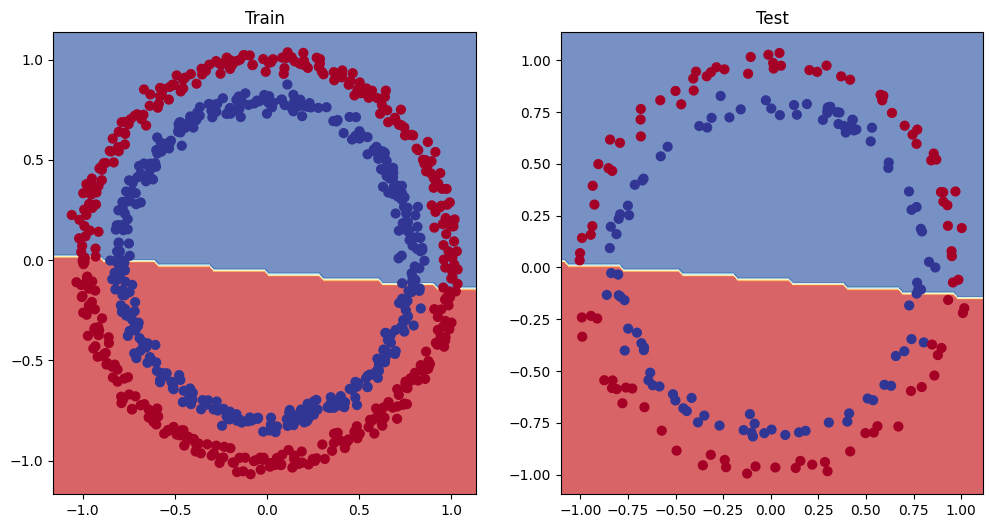

In [99]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)


## 5. Improving the model
* Add more layers - give the model more layer to learn more pattern
* Add more hidden units
* Train more epochs
* Changing the activation function
* Change the learning rate
* Change the loss function

In [100]:
# model_1 = nn.Sequential(
#     nn.Linear(in_features=2, out_features=256),
#     nn.ReLU(),
#     nn.Linear(in_features=256, out_features=128),
#     nn.ReLU(),
#     nn.Linear(in_features=128, out_features=64),
#     nn.ReLU(),
#     nn.Linear(in_features=64, out_features=1),
# ).to(device)

class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    # self.layer_1 = nn.Linear(in_features=2, out_features=256)
    # self.layer_2 = nn.Linear(in_features=256, out_features=128)
    # self.layer_3 = nn.Linear(in_features=128, out_features=64)
    # self.layer_4 = nn.Linear(in_features=64, out_features=1)
    # self.relu = nn.ReLU()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    z = self.layer_1(x)
    # a = self.relu(z)
    z = self.layer_2(z)
    # a = self.relu(z)
    z = self.layer_3(z)
    # a = self.relu(z)
    return z

torch.manual_seed(42)
model_1 = CircleModelV1().to(device)


In [101]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [102]:
torch.cuda.manual_seed(42) if torch.cuda.is_available() else torch.manual_seed(42)
epochs = 1000

X_train, y_train, X_test, y_test = X_train.to(device), y_train.to(device), X_test.to(device), y_test.to(device)

for e in range(epochs):
  model_1.train()

  # 1. forward pass
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  train_loss = loss_fn(y_logits, y_train)
  # train_loss = loss_fn(y_pred, y_train) # if the lossfn was BCE then we have to pass the pred

  train_acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  optimizer.zero_grad()

  train_loss.backward()

  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)
    if e % 20 == 0:
      print(f"Epoch: {e} | Train Loss: {train_loss:.5f} | Test Loss: {test_loss:.5f} | Train Accuracy: {train_acc:.2f} | Test Accuracy: {test_acc:.2f}")

Epoch: 0 | Train Loss: 0.69396 | Test Loss: 0.69261 | Train Accuracy: 50.88 | Test Accuracy: 51.00
Epoch: 20 | Train Loss: 0.69351 | Test Loss: 0.69283 | Train Accuracy: 50.12 | Test Accuracy: 49.50
Epoch: 40 | Train Loss: 0.69329 | Test Loss: 0.69310 | Train Accuracy: 50.38 | Test Accuracy: 49.00
Epoch: 60 | Train Loss: 0.69317 | Test Loss: 0.69336 | Train Accuracy: 49.38 | Test Accuracy: 51.50
Epoch: 80 | Train Loss: 0.69309 | Test Loss: 0.69359 | Train Accuracy: 50.12 | Test Accuracy: 50.00
Epoch: 100 | Train Loss: 0.69305 | Test Loss: 0.69379 | Train Accuracy: 50.38 | Test Accuracy: 48.00
Epoch: 120 | Train Loss: 0.69302 | Test Loss: 0.69396 | Train Accuracy: 50.75 | Test Accuracy: 46.50
Epoch: 140 | Train Loss: 0.69301 | Test Loss: 0.69409 | Train Accuracy: 51.00 | Test Accuracy: 48.00
Epoch: 160 | Train Loss: 0.69300 | Test Loss: 0.69421 | Train Accuracy: 51.12 | Test Accuracy: 47.00
Epoch: 180 | Train Loss: 0.69299 | Test Loss: 0.69430 | Train Accuracy: 51.12 | Test Accuracy: 46

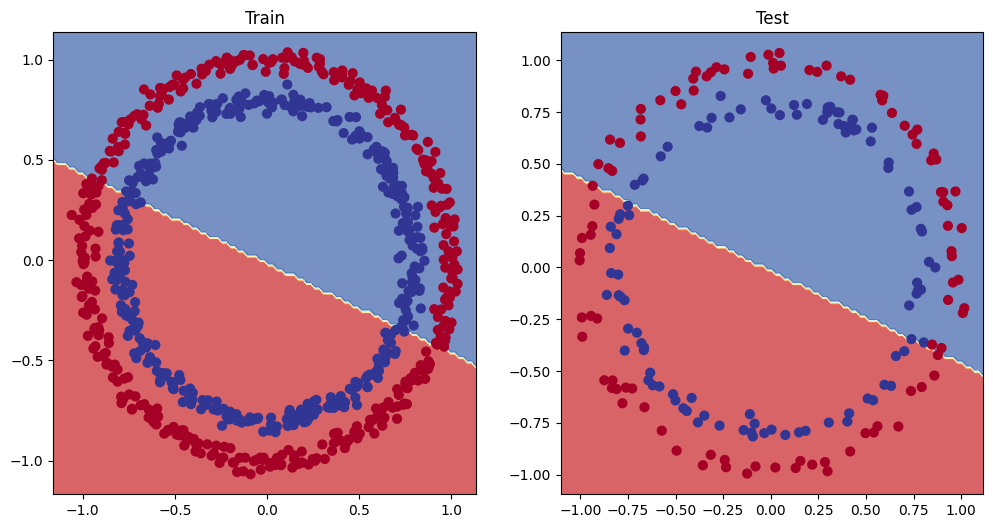

In [103]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)
# Still no improvement even after incresing epoch, hiddin unit and layers

## lets check if out model can fit properly on different type of data, this is one way to trouble shoot

In [104]:
# Create some data
w = 0.7
b = 0.3

X_regression = torch.arange(0,1,0.01).unsqueeze(dim=1)
y_regression = w * X_regression + b

# Create train and test splits
from sklearn.model_selection import train_test_split
X_train_regression, X_test_regression, y_train_regression, y_test_regression = train_test_split(X_regression, y_regression, train_size=0.8, random_state=42)
len(X_train_regression), len(X_test_regression)

(80, 20)

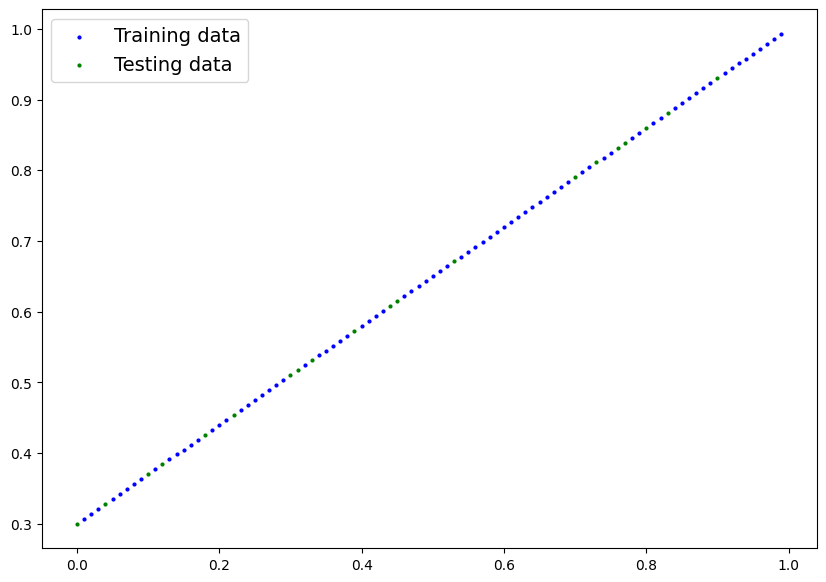

In [105]:
plot_predictions(X_train_regression, y_train_regression, X_test_regression, y_test_regression
)

### Adjusting `model_1 ` to fit to straight line
# Same arc as model_1 but using nn.sequential

In [106]:
model_2 = nn.Sequential(nn.Linear(1,10),
                        nn.Linear(10,10),
                        nn.Linear(10,1)).to(device)
model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [107]:
# Loss and optim
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

In [108]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)
# Train
for e in range(epochs):
  model_2.train()
  y_pred = model_2(X_train_regression)
  train_loss = loss_fn(y_pred, y_train_regression)
  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)

  if e % 100 == 0:
    print(f"Epoch: {e} | Train Loss: {train_loss:.5f} | Test Loss: {test_loss:.2f}")

Epoch: 0 | Train Loss: 0.80353 | Test Loss: 0.74
Epoch: 100 | Train Loss: 0.02930 | Test Loss: 0.01
Epoch: 200 | Train Loss: 0.02346 | Test Loss: 0.02
Epoch: 300 | Train Loss: 0.02341 | Test Loss: 0.02
Epoch: 400 | Train Loss: 0.02382 | Test Loss: 0.02
Epoch: 500 | Train Loss: 0.02303 | Test Loss: 0.02
Epoch: 600 | Train Loss: 0.02270 | Test Loss: 0.01
Epoch: 700 | Train Loss: 0.02148 | Test Loss: 0.01
Epoch: 800 | Train Loss: 0.02129 | Test Loss: 0.01
Epoch: 900 | Train Loss: 0.02147 | Test Loss: 0.01


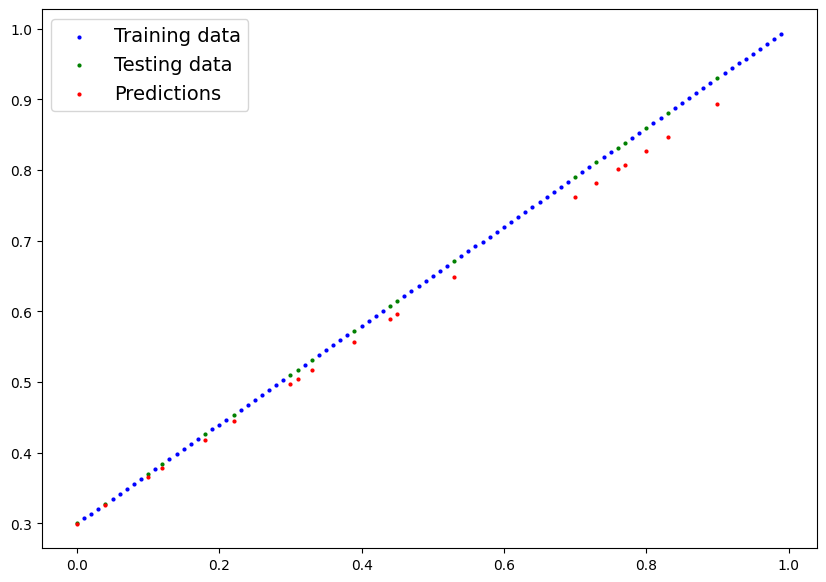

In [109]:
model_2.eval()
with torch.inference_mode():
  y_preds = model_2(X_test_regression)
plot_predictions(predictions=y_preds.cpu(),
                 train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu())

## The missing peive is the non linear activation function like relu, tanh, etc

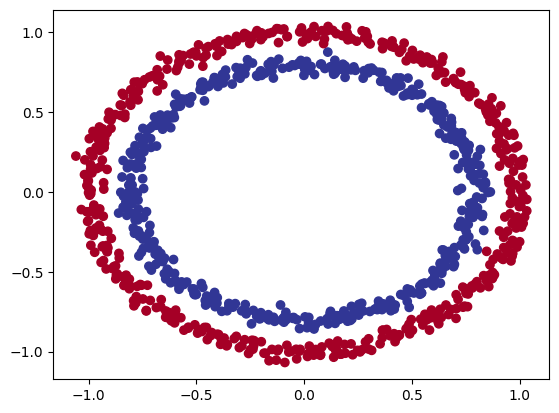

In [110]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)

In [111]:
# Convert data to tensors and then to train and test splits

import torch

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
len(X_train), len(X_test)

(800, 200)

In [112]:
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(2,10)
    self.layer_2 = nn.Linear(10,10)
    self.layer_3 = nn.Linear(10,1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [113]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)

## Training a model with non linearity

In [114]:
# Random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 2000
for e in range(epochs):
  model_3.train()

  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  train_loss = loss_fn(y_logits, y_train)
  train_acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)


  if e % 100 == 0:
    print(f"Epoch: {e} \nLoss: {train_loss:.4f} | Test Loss: {test_loss:.4f} \n Accuracy: {train_acc:.2f} | Test Accuracy: {test_acc:.2f}")

Epoch: 0 
Loss: 0.6929 | Test Loss: 0.6932 
 Accuracy: 50.00 | Test Accuracy: 50.00
Epoch: 100 
Loss: 0.6912 | Test Loss: 0.6910 
 Accuracy: 52.88 | Test Accuracy: 52.50
Epoch: 200 
Loss: 0.6898 | Test Loss: 0.6894 
 Accuracy: 53.37 | Test Accuracy: 55.00
Epoch: 300 
Loss: 0.6879 | Test Loss: 0.6872 
 Accuracy: 53.00 | Test Accuracy: 56.00
Epoch: 400 
Loss: 0.6852 | Test Loss: 0.6841 
 Accuracy: 52.75 | Test Accuracy: 56.50
Epoch: 500 
Loss: 0.6810 | Test Loss: 0.6794 
 Accuracy: 52.75 | Test Accuracy: 56.50
Epoch: 600 
Loss: 0.6751 | Test Loss: 0.6729 
 Accuracy: 54.50 | Test Accuracy: 56.00
Epoch: 700 
Loss: 0.6666 | Test Loss: 0.6632 
 Accuracy: 58.38 | Test Accuracy: 59.00
Epoch: 800 
Loss: 0.6516 | Test Loss: 0.6476 
 Accuracy: 64.00 | Test Accuracy: 67.50
Epoch: 900 
Loss: 0.6236 | Test Loss: 0.6215 
 Accuracy: 74.00 | Test Accuracy: 79.00
Epoch: 1000 
Loss: 0.5682 | Test Loss: 0.5738 
 Accuracy: 87.75 | Test Accuracy: 86.50
Epoch: 1100 
Loss: 0.4815 | Test Loss: 0.4993 
 Accurac

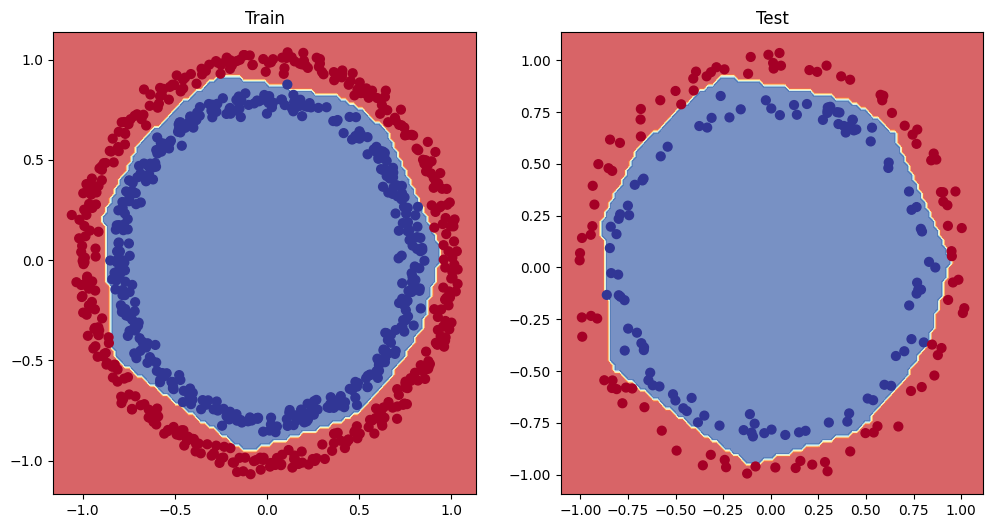

In [115]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1) # (no of rows, no of cols, index)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
model_3.eval()
with torch.inference_mode():
  plot_decision_boundary(model_3, X_test, y_test)


# Building a multi Class classification

In [116]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# set params for data creation
NUM_CLASSES = 5
NUM_FEATURES = 2
RANDOM_SEED = 4

X_blob, y_blob = make_blobs(1000, NUM_FEATURES, centers=NUM_CLASSES, cluster_std=1, random_state=RANDOM_SEED)

X_blob

array([[ 9.61192081, -7.75121795],
       [ 9.61255784,  5.07929544],
       [11.26953999,  4.63457281],
       ...,
       [-5.16333045, -0.98468017],
       [ 9.58416749,  3.77563826],
       [-5.27168211, -1.5851402 ]])

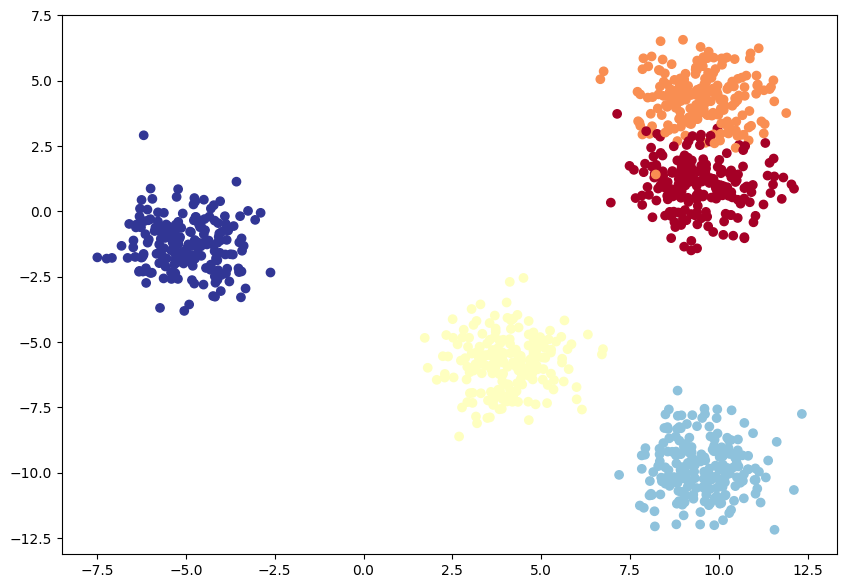

In [117]:
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

X_train_blob, X_test_blob, y_train_blob, y_test_blob = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)

# VISUALIZATION
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0], X_blob[:,1], c=y_blob,cmap=plt.cm.RdYlBu)

In [118]:
## 82. Building a multi class classification
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [119]:
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=16):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(input_features, hidden_units),
        nn.ReLU(),
        nn.Linear(hidden_units, hidden_units),
        nn.ReLU(),
        nn.Linear(hidden_units, hidden_units),
        nn.ReLU(),
        nn.Linear(hidden_units, hidden_units),
        nn.ReLU(),
        nn.Linear(hidden_units, hidden_units),
        nn.ReLU(),
        nn.Linear(hidden_units, hidden_units),
        nn.ReLU(),
        nn.Linear(hidden_units, hidden_units),
        nn.ReLU(),
        nn.Linear(hidden_units, output_features)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

blob_model_1 = BlobModel(input_features=NUM_FEATURES, output_features=NUM_CLASSES).to(device)
blob_model_1

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=16, bias=True)
    (11): ReLU()
    (12): Linear(in_features=16, out_features=16, bias=True)
    (13): ReLU()
    (14): Linear(in_features=16, out_features=5, bias=True)
  )
)

### 8.3 Create a loss function and optimizer

In [120]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=blob_model_1.parameters(), lr=0.01)

### we need to logits -> pred probs -> pred labels

In [121]:
y_logits = blob_model_1(X_train_blob.to(device))
y_logits[:10]

tensor([[-0.1669, -0.1196, -0.3201, -0.0032, -0.0691],
        [-0.1667, -0.1199, -0.3202, -0.0027, -0.0685],
        [-0.1674, -0.1190, -0.3200, -0.0040, -0.0666],
        [-0.1667, -0.1196, -0.3196, -0.0033, -0.0685],
        [-0.1672, -0.1192, -0.3202, -0.0036, -0.0668],
        [-0.1667, -0.1200, -0.3203, -0.0025, -0.0687],
        [-0.1664, -0.1197, -0.3196, -0.0030, -0.0687],
        [-0.1666, -0.1200, -0.3202, -0.0026, -0.0684],
        [-0.1668, -0.1197, -0.3202, -0.0030, -0.0676],
        [-0.1667, -0.1205, -0.3213, -0.0020, -0.0708]],
       grad_fn=<SliceBackward0>)

In [122]:
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs[:10]

tensor([[0.1928, 0.2021, 0.1654, 0.2271, 0.2126],
        [0.1928, 0.2020, 0.1654, 0.2271, 0.2127],
        [0.1926, 0.2022, 0.1654, 0.2268, 0.2130],
        [0.1928, 0.2021, 0.1654, 0.2270, 0.2127],
        [0.1927, 0.2021, 0.1653, 0.2269, 0.2130],
        [0.1928, 0.2020, 0.1653, 0.2272, 0.2126],
        [0.1928, 0.2020, 0.1654, 0.2271, 0.2126],
        [0.1928, 0.2020, 0.1653, 0.2272, 0.2127],
        [0.1927, 0.2020, 0.1653, 0.2270, 0.2128],
        [0.1929, 0.2020, 0.1653, 0.2274, 0.2123]], grad_fn=<SliceBackward0>)

In [123]:
# Convert our model prediction probabilities as prediction labels
y_pred_labels = torch.argmax(y_pred_probs, dim=1)
y_pred_labels[:10]

tensor([3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

### CREATING TRAINING AND TESTING LOOP

In [124]:
epochs = 1000

for e in range(epochs):
  blob_model_1.train()
  y_logits = blob_model_1(X_train_blob)
  y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)

  loss = loss_fn(y_logits, y_train_blob)
  acc = accuracy_fn(y_true=y_train_blob, y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  blob_model_1.eval()
  with torch.inference_mode():
    test_logits = blob_model_1(X_test_blob)
    test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits, y_test_blob)
    test_acc = accuracy_fn(y_true=y_test_blob, y_pred=test_preds)
    if e % 100 == 0:
      print(f"Epoch {e}\nAccuracy: {acc} | Test Accurac: {test_acc}\nLoss: {loss} | Test Loss: {test_loss}")

Epoch 0
Accuracy: 20.375 | Test Accurac: 18.5
Loss: 1.613694190979004 | Test Loss: 1.6232496500015259
Epoch 100
Accuracy: 20.375 | Test Accurac: 18.5
Loss: 1.6114983558654785 | Test Loss: 1.6193547248840332
Epoch 200
Accuracy: 20.375 | Test Accurac: 18.5
Loss: 1.6102632284164429 | Test Loss: 1.6168328523635864
Epoch 300
Accuracy: 20.375 | Test Accurac: 18.5
Loss: 1.6095494031906128 | Test Loss: 1.6151355504989624
Epoch 400
Accuracy: 20.375 | Test Accurac: 18.5
Loss: 1.609092354774475 | Test Loss: 1.613929271697998
Epoch 500
Accuracy: 20.375 | Test Accurac: 18.5
Loss: 1.6087620258331299 | Test Loss: 1.6130316257476807
Epoch 600
Accuracy: 20.375 | Test Accurac: 18.5
Loss: 1.6084938049316406 | Test Loss: 1.612332820892334
Epoch 700
Accuracy: 20.375 | Test Accurac: 18.5
Loss: 1.608222246170044 | Test Loss: 1.6117372512817383
Epoch 800
Accuracy: 24.125 | Test Accurac: 24.5
Loss: 1.607899785041809 | Test Loss: 1.611175537109375
Epoch 900
Accuracy: 40.875 | Test Accurac: 36.5
Loss: 1.60734081

In [125]:
blob_model_1.eval()
with torch.inference_mode():
  y_logits = blob_model_1(X_test_blob)

y_logits[:10]

tensor([[-0.1615, -0.1270, -0.1699, -0.1068, -0.1085],
        [-0.1632, -0.1256, -0.1692, -0.1101, -0.1054],
        [-0.1624, -0.1269, -0.1692, -0.1083, -0.1061],
        [-0.1618, -0.1268, -0.1699, -0.1073, -0.1082],
        [-0.1604, -0.1323, -0.1734, -0.0995, -0.1107],
        [-0.1626, -0.1264, -0.1709, -0.1077, -0.1090],
        [-0.1606, -0.1325, -0.1739, -0.0991, -0.1111],
        [-0.1629, -0.1259, -0.1690, -0.1098, -0.1052],
        [-0.1631, -0.1262, -0.1717, -0.1077, -0.1102],
        [-0.1615, -0.1285, -0.1702, -0.1058, -0.1072]])

In [126]:
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs[:10]

tensor([[0.1947, 0.2015, 0.1930, 0.2056, 0.2052],
        [0.1943, 0.2017, 0.1932, 0.2049, 0.2059],
        [0.1944, 0.2015, 0.1931, 0.2053, 0.2057],
        [0.1946, 0.2015, 0.1930, 0.2055, 0.2053],
        [0.1950, 0.2005, 0.1924, 0.2072, 0.2049],
        [0.1945, 0.2017, 0.1929, 0.2055, 0.2053],
        [0.1950, 0.2005, 0.1924, 0.2073, 0.2048],
        [0.1943, 0.2017, 0.1932, 0.2049, 0.2059],
        [0.1945, 0.2019, 0.1929, 0.2056, 0.2051],
        [0.1946, 0.2012, 0.1929, 0.2058, 0.2055]])

In [127]:
y_pred = y_pred_probs.argmax(dim=1)
y_pred == y_test_blob

tensor([False,  True, False, False,  True, False,  True,  True, False, False,
        False,  True, False,  True, False, False,  True, False, False, False,
        False, False,  True,  True, False,  True, False, False, False,  True,
        False,  True,  True, False, False,  True, False, False, False, False,
        False, False, False,  True,  True, False, False, False, False, False,
        False, False,  True, False,  True,  True, False, False, False, False,
         True, False, False,  True, False,  True,  True, False, False, False,
        False,  True,  True,  True, False, False,  True, False,  True, False,
        False, False, False,  True, False,  True,  True,  True, False, False,
         True, False, False, False, False,  True, False, False,  True,  True,
        False,  True,  True,  True,  True, False, False, False,  True, False,
         True, False, False,  True, False, False,  True, False, False, False,
        False,  True,  True, False, False,  True, False, False, 

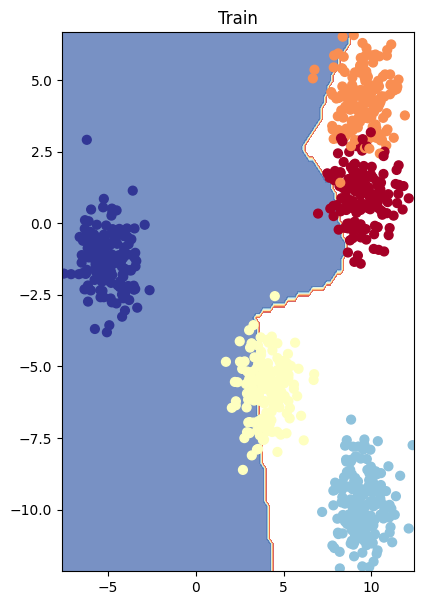

In [128]:
plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(blob_model_1,X_train_blob, y_train_blob)

## 9. Few More Classification metrics
* Accuracy - `torchmdetrics.Accuracy()` - not good for imbalance dataset
* Precision - `torchmdetrics.Precision()` - high precision leads to less false positive
* Recall - `torchmdetrics.Recall()` - Higher recall leads to less false negative
* F1-score - `torchmdetrics.F1Score()` - Combination of precision and recall
* Confusion matrix - `torchmdetrics.ConfuusionMatrix()` - To check where the model get confused by comparing the true and pred. hard to use with large numbers of classes
* Classification report -


In [129]:
!pip install torchmetrics

# Exercise for 02

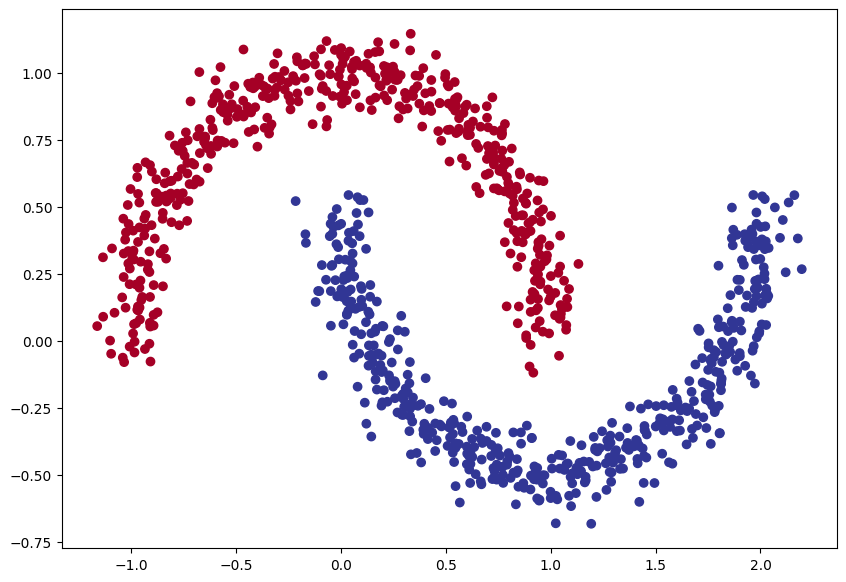

In [160]:
from sklearn.datasets import make_moons

X_moon, y_moon = make_moons(n_samples=1000, noise=0.075, random_state=42)
plt.figure(figsize=(10,7))
plt.scatter(X_moon[:,0], X_moon[:,1], c=y_moon,cmap=plt.cm.RdYlBu)
X_train,X_test,y_train, y_test = train_test_split(X_moon, y_moon, test_size=0.2, random_state=42)


In [161]:
NUM_LAYER = 5
NUM_HIDDEN = 20

class MoonModelV1(nn.Module):
  def __init__(self, num_output=1, num_input=2, num_layer=NUM_LAYER, num_hidden=NUM_HIDDEN):
    super().__init__()
    layers = []
    for i in range(num_layer):
      if i == 0: # First Layer
        layers.extend([nn.Linear(num_input,num_hidden), nn.ReLU()])
      elif i == num_layer - 1: # Last Layer
        layers.append(nn.Linear(num_hidden,num_output))
      else: # Between
        layers.extend([nn.Linear(num_hidden,num_hidden), nn.ReLU()])
    self.layer_stack = nn.Sequential(*layers)

  def forward(self, x):
    return self.layer_stack(x)

In [162]:
moon_model = MoonModelV1()
moon_model

MoonModelV1(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=20, bias=True)
    (5): ReLU()
    (6): Linear(in_features=20, out_features=20, bias=True)
    (7): ReLU()
    (8): Linear(in_features=20, out_features=1, bias=True)
  )
)

In [163]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=moon_model.parameters(), lr=0.1)


In [164]:
from torchmetrics.classification import Accuracy
if type(X_train) != torch.Tensor:
  X_train = torch.from_numpy(X_train).type(torch.float)
  X_test = torch.from_numpy(X_test).type(torch.float)
  y_train = torch.from_numpy(y_train).type(torch.float)
  y_test = torch.from_numpy(y_test).type(torch.float)

epochs = 1000
accuracy_fn = Accuracy(task="binary")
for e in range(epochs):
  moon_model.train()

  logits = moon_model(X_train).squeeze()
  pred = torch.round(torch.sigmoid(logits))

  loss = loss_fn(logits, y_train)
  acc = accuracy_fn(pred, y_train)
  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  moon_model.eval()
  with torch.inference_mode():
    test_logits = moon_model(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(test_pred, y_test)

    if e % 100 == 0:
      print(f"Epoch: {e} \nLoss: {loss:.2f} | Test Loss: {test_loss:.2f} \n Accuracy: {acc:.2f} | Test Accuracy: {test_acc:.2f}")


Epoch: 0 
Loss: 0.69 | Test Loss: 0.69 
 Accuracy: 0.50 | Test Accuracy: 0.50
Epoch: 100 
Loss: 0.68 | Test Loss: 0.68 
 Accuracy: 0.72 | Test Accuracy: 0.71
Epoch: 200 
Loss: 0.40 | Test Loss: 0.40 
 Accuracy: 0.86 | Test Accuracy: 0.83
Epoch: 300 
Loss: 0.13 | Test Loss: 0.12 
 Accuracy: 0.94 | Test Accuracy: 0.95
Epoch: 400 
Loss: 0.03 | Test Loss: 0.03 
 Accuracy: 1.00 | Test Accuracy: 1.00
Epoch: 500 
Loss: 0.01 | Test Loss: 0.01 
 Accuracy: 1.00 | Test Accuracy: 1.00
Epoch: 600 
Loss: 0.01 | Test Loss: 0.00 
 Accuracy: 1.00 | Test Accuracy: 1.00
Epoch: 700 
Loss: 0.00 | Test Loss: 0.00 
 Accuracy: 1.00 | Test Accuracy: 1.00
Epoch: 800 
Loss: 0.00 | Test Loss: 0.00 
 Accuracy: 1.00 | Test Accuracy: 1.00
Epoch: 900 
Loss: 0.00 | Test Loss: 0.00 
 Accuracy: 1.00 | Test Accuracy: 1.00


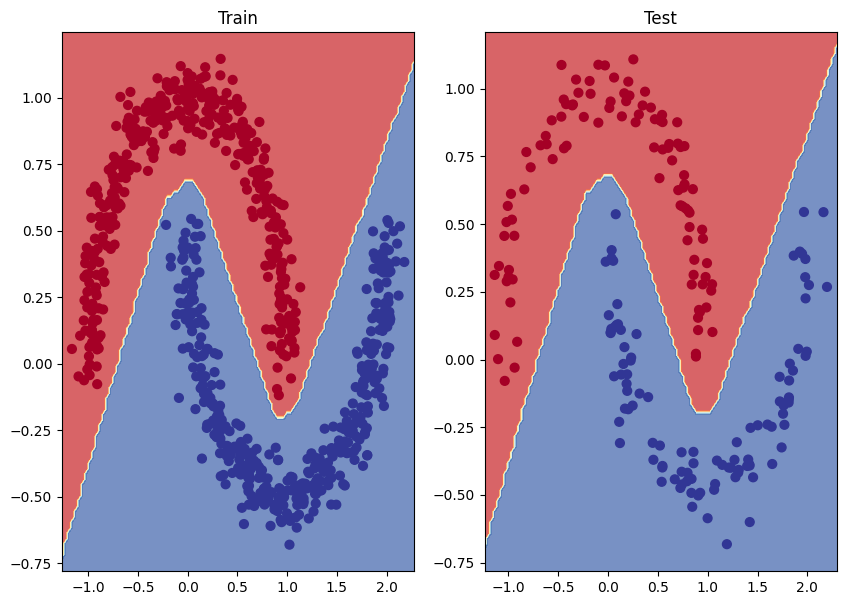

In [165]:
plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(moon_model, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(moon_model, X_test, y_test)

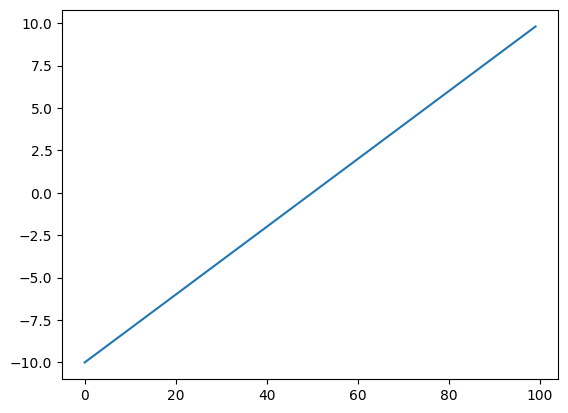

In [166]:
X = torch.arange(-10,10,0.2)
plt.plot(X)

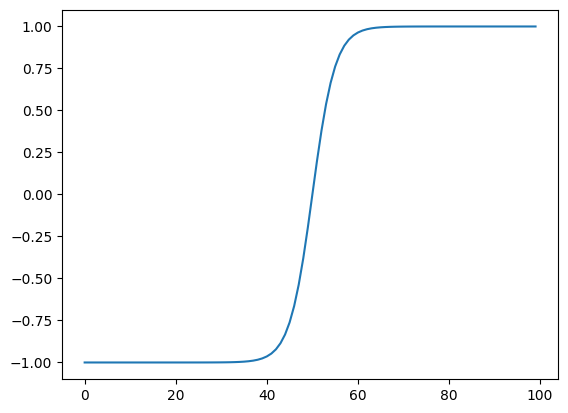

In [167]:
def tanh(x:torch.Tensor) -> torch.Tensor:
  return ((torch.exp(x) - torch.exp(-x))/(torch.exp(x) + torch.exp(-x)))

plt.plot(tanh(X))

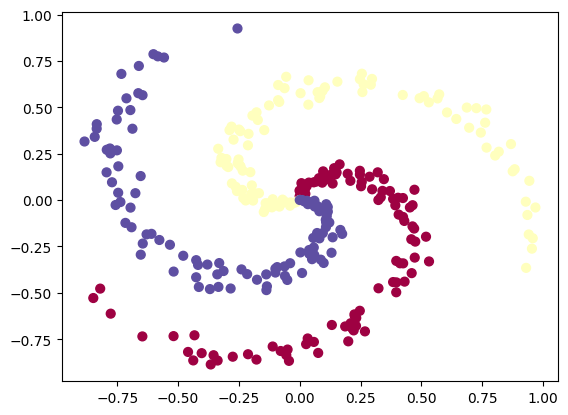

In [177]:
import numpy as np
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [191]:
spiral_model = MoonModelV1(num_output=3, num_input=2, num_hidden=20, num_layer=6)
spiral_model

MoonModelV1(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=20, bias=True)
    (5): ReLU()
    (6): Linear(in_features=20, out_features=20, bias=True)
    (7): ReLU()
    (8): Linear(in_features=20, out_features=20, bias=True)
    (9): ReLU()
    (10): Linear(in_features=20, out_features=3, bias=True)
  )
)

In [192]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=spiral_model.parameters(), lr=0.01)

In [193]:
if type(X) != torch.Tensor:
  X = torch.from_numpy(X).type(torch.float)
  y = torch.from_numpy(y).type(torch.LongTensor)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)
len(X_train), len(X_test)

(240, 60)

In [194]:
epochs = 1000

accuracy_fn = Accuracy(task="multiclass", num_classes=3)

for e in range(epochs):
  spiral_model.train()
  logits = spiral_model(X_train)
  pred = torch.softmax(logits, dim=1).argmax(dim=1)

  loss = loss_fn(logits, y_train)
  acc = accuracy_fn(pred, y_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  spiral_model.eval()
  with torch.inference_mode():
    test_logits = spiral_model(X_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(test_pred, y_test)

    if e % 100 == 0:
      print(f"Epoch: {e}\nLoss: {loss:.5f} | Test Loss:{test_loss:.5f}\n Accuracy: {acc:.2f} | Test Accuracy: {test_acc:.2f}")

Epoch: 0
Loss: 1.10444 | Test Loss:1.10302
 Accuracy: 0.34 | Test Accuracy: 0.32
Epoch: 100
Loss: 0.02573 | Test Loss:0.01875
 Accuracy: 0.99 | Test Accuracy: 1.00
Epoch: 200
Loss: 0.11107 | Test Loss:0.11854
 Accuracy: 0.96 | Test Accuracy: 0.93
Epoch: 300
Loss: 0.01681 | Test Loss:0.02613
 Accuracy: 0.99 | Test Accuracy: 0.98
Epoch: 400
Loss: 0.01538 | Test Loss:0.00832
 Accuracy: 0.99 | Test Accuracy: 1.00
Epoch: 500
Loss: 0.01473 | Test Loss:0.00534
 Accuracy: 0.99 | Test Accuracy: 1.00
Epoch: 600
Loss: 0.01439 | Test Loss:0.00453
 Accuracy: 0.99 | Test Accuracy: 1.00
Epoch: 700
Loss: 0.01508 | Test Loss:0.00479
 Accuracy: 0.99 | Test Accuracy: 1.00
Epoch: 800
Loss: 0.01474 | Test Loss:0.00577
 Accuracy: 0.99 | Test Accuracy: 1.00
Epoch: 900
Loss: 0.01462 | Test Loss:0.00941
 Accuracy: 0.99 | Test Accuracy: 1.00


In [195]:
def plot_and_compare(model, X_train, y_train, X_test, y_test):
  plt.figure(figsize=(12,6))
  plt.subplot(1,2,1)
  plt.title("Train")
  plot_decision_boundary(model, X_train, y_train)
  plt.subplot(1,2,2)
  plt.title("Test")
  plot_decision_boundary(model, X_test, y_test)

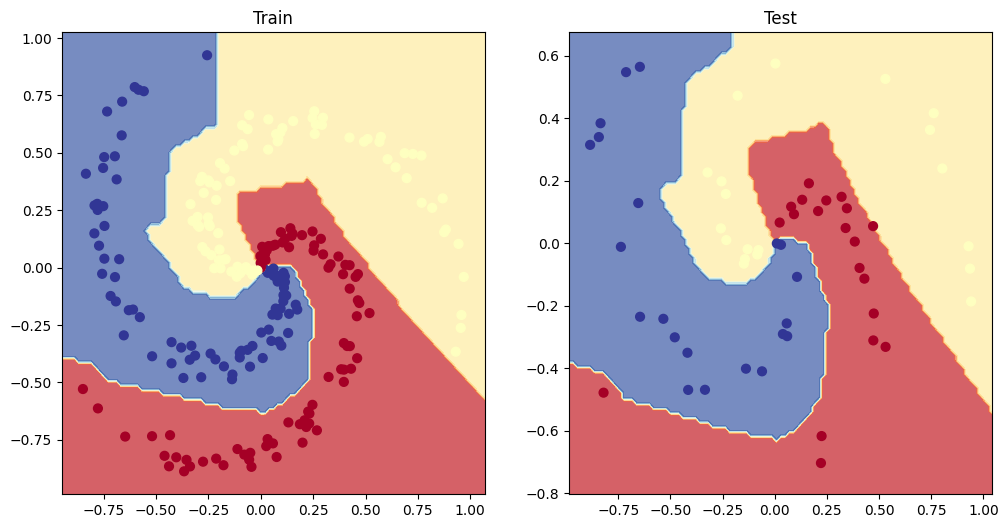

In [196]:
plot_and_compare(spiral_model, X_train, y_train, X_test, y_test)